# MEC 2026 - Online Music Alignment with Matchmaker (Symbolic)

**Music Alignment Workshop, MEC 2026 — Section 3 (Online Alignment), Part 2 (Symbolic)**

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/pymatchmaker/mec2026_alignment_workshop/blob/online-symbolic-alignment/notebooks/online_alignment_symbolic.ipynb)

This notebook accompanies the online alignment section of **Music Alignment Uncovered: Representations, Algorithms and Hands-On Tools** at MEC 2026.

In this notebook we align **one MIDI recording and the corresponding score** using the [Matchmaker](https://github.com/pymatchmaker/matchmaker) package. 

## 0. Setup

Run the setup cells once at the beginning. If you already installed the dependencies, you may skip the installation cells.

Workshop resources live under `mec-variation/` at the repo root. Make sure that directory is present alongside this notebook (clone the workshop repo if you haven't).

For audio score following, Matchmaker may need FluidSynth and libsndfile. In Colab the apt cell below installs them; locally install them via your system package manager, e.g. `conda install -c conda-forge fluidsynth libsndfile`.

In [1]:
# Colab-only system dependencies.
# Local users can install these separately, e.g.:
# conda install -c conda-forge fluidsynth libsndfile

import importlib.util
import shutil
import subprocess

try:
    IN_COLAB = importlib.util.find_spec("google.colab") is not None
except ModuleNotFoundError:
    IN_COLAB = False

if IN_COLAB and shutil.which("apt-get") is not None:
    subprocess.run(["apt-get", "update", "-qq"], check=True)
    subprocess.run(
        ["apt-get", "install", "-y", "-qq", "fluidsynth", "libsndfile1"],
        check=True,
    )
else:
    print("Skipping apt-get setup outside Colab.")

Skipping apt-get setup outside Colab.


In [ ]:
# Python dependencies.
# pymatchmaker pulls in the main alignment stack; the other packages are used
# directly in this notebook for plotting, data inspection, and audio features.

%pip install -q "setuptools>=80,<81" "numpy>=1.26.3,<2.0" pymatchmaker pandas matplotlib librosa partitura ipython

In [51]:
import json
import warnings
import librosa
import matchmaker as mm
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np
import pandas as pd
import partitura as pt
from IPython.display import Audio, Image, display, clear_output
from pathlib import Path
from queue import Empty
from matchmaker import Matchmaker
from matchmaker.features.audio import ChromagramProcessor, CQTProcessor, CQTSpectralFluxProcessor
from matchmaker.features.midi import onset_pianoroll, PitchClassPianoRollProcessor, ChordOnsetProcessor, CHORD_THRESHOLD
from matchmaker.matchmaker import AVAILABLE_METHODS, DEFAULT_METHOD, DEFAULT_PROCESSOR
from matchmaker.io.stream import STREAM_END
from matchmaker.io.audio import QUEUE_TIMEOUT

warnings.filterwarnings("ignore", category=np.exceptions.ComplexWarning)
warnings.filterwarnings("ignore", category=UserWarning, module="partitura")
warnings.filterwarnings("ignore", category=UserWarning, module="hiddenmarkov")
print("matchmaker", mm.__version__)

matchmaker 0.2.1


In [42]:
DATA_DIR = Path("../mec-variation")
SCORE_FILE = DATA_DIR / "scores/musicxml/short.musicxml"
AUDIO_FILE = DATA_DIR / "performances/wav/short1.wav"
MIDI_FILE = DATA_DIR / "performances/midi/short1.mid"
MATCH_FILE = DATA_DIR / "alignments/match/short1.match"
SNIPPET_FILE = DATA_DIR / "performances/wav/snippet.wav"
MIDI_SNIPPET_FILE = DATA_DIR / "performances/midi/snippet.mid"
SNIPPET_SCORE_FILE = DATA_DIR / "scores/musicxml/snippet.musicxml"
PREVIEW_IMAGE = DATA_DIR / "scores/simple_mozart_first_two_measures.png"

# Ground-truth note onsets (seconds) from the .match file.
NOTE_ANNOTATIONS = pt.load_match(str(MATCH_FILE))[0].note_array()["onset_sec"]

print("Data directory:", DATA_DIR.resolve())
for path in [SCORE_FILE, AUDIO_FILE, MIDI_FILE, MATCH_FILE, SNIPPET_FILE, PREVIEW_IMAGE]:
    print(path.name, "ok" if path.exists() else "missing")
print(f"NOTE_ANNOTATIONS: {len(NOTE_ANNOTATIONS)} note onsets from {MATCH_FILE.name}")

Data directory: /home/suhit/JKU/Repos/mec2026_alignment_workshop/mec-variation
short.musicxml ok
short1.wav ok
short1.mid ok
short1.match ok
snippet.wav ok
simple_mozart_first_two_measures.png ok
NOTE_ANNOTATIONS: 219 note onsets from short1.match


## 1. MIDI vs. Audio Online Alignment

### Representation

- **Audio alignment**
  - Operates directly on acoustic signals (waveforms or spectrograms).
  - Captures expressive performance details such as timbre, articulation, dynamics, and room acoustics.

- **MIDI alignment**
  - Operates on symbolic note events (pitch, onset, offset, velocity).
  - Represents musical structure abstractly, independent of instrument sound.

---


#### Advantages of MIDI
- No processing is required to decipher the musical note being played.
- Precise note onset and offset timing.
- Faster and cleaner feature extraction and matching --> lower latency.
- Robust to noise, timbre, and recording conditions.

#### Disadvantages of MIDI
- Loses expressive acoustic information (timbre, articulation, dynamics).
- MIDI is most naturally suited to piano/keyboard-style/percussion note events;
  but not to instruments such as the violin or the human voice, 
  which would depend on the transcription of their audio signals into MIDI information.
- In comparison to audio recordings, fewer MIDI recordings of performances are available.

---

## 2. MIDI Features

The `MidiStream` in Matchmaker is responsible for sending the input MIDI data (either in windowed frames, or by note event) through a `Processor` that returns one feature vector.

Let's look at two processors in this segment of the workshop:

- `PitchClassPianoRollProcessor` — Equivalent to a 12-bin chroma representation in audio processing. Both the input MIDI and the reference score features are reduced to 12 pitch-class values. This processor is used by the Particle Filter method.
- `ChordOnsetProcessor` — Processes incoming note events by setting the corresponding pitch indices in the feature vector to 1 whenever a note is observed. If multiple note events occur within a 10 ms window, it produces a multi-hot vector representing all detected pitches. Depending on the selected pitch range, the processor outputs either an 88-bin vector (piano range) or a full 128-bin vector. This processor is used by the Outer Product HMM method.

#### Let's first look again at the score snippet that we are working with, and listen to the MIDI snippet of the same

Below is the short score snippet again, along with the MIDI snippet (first 2 measures).


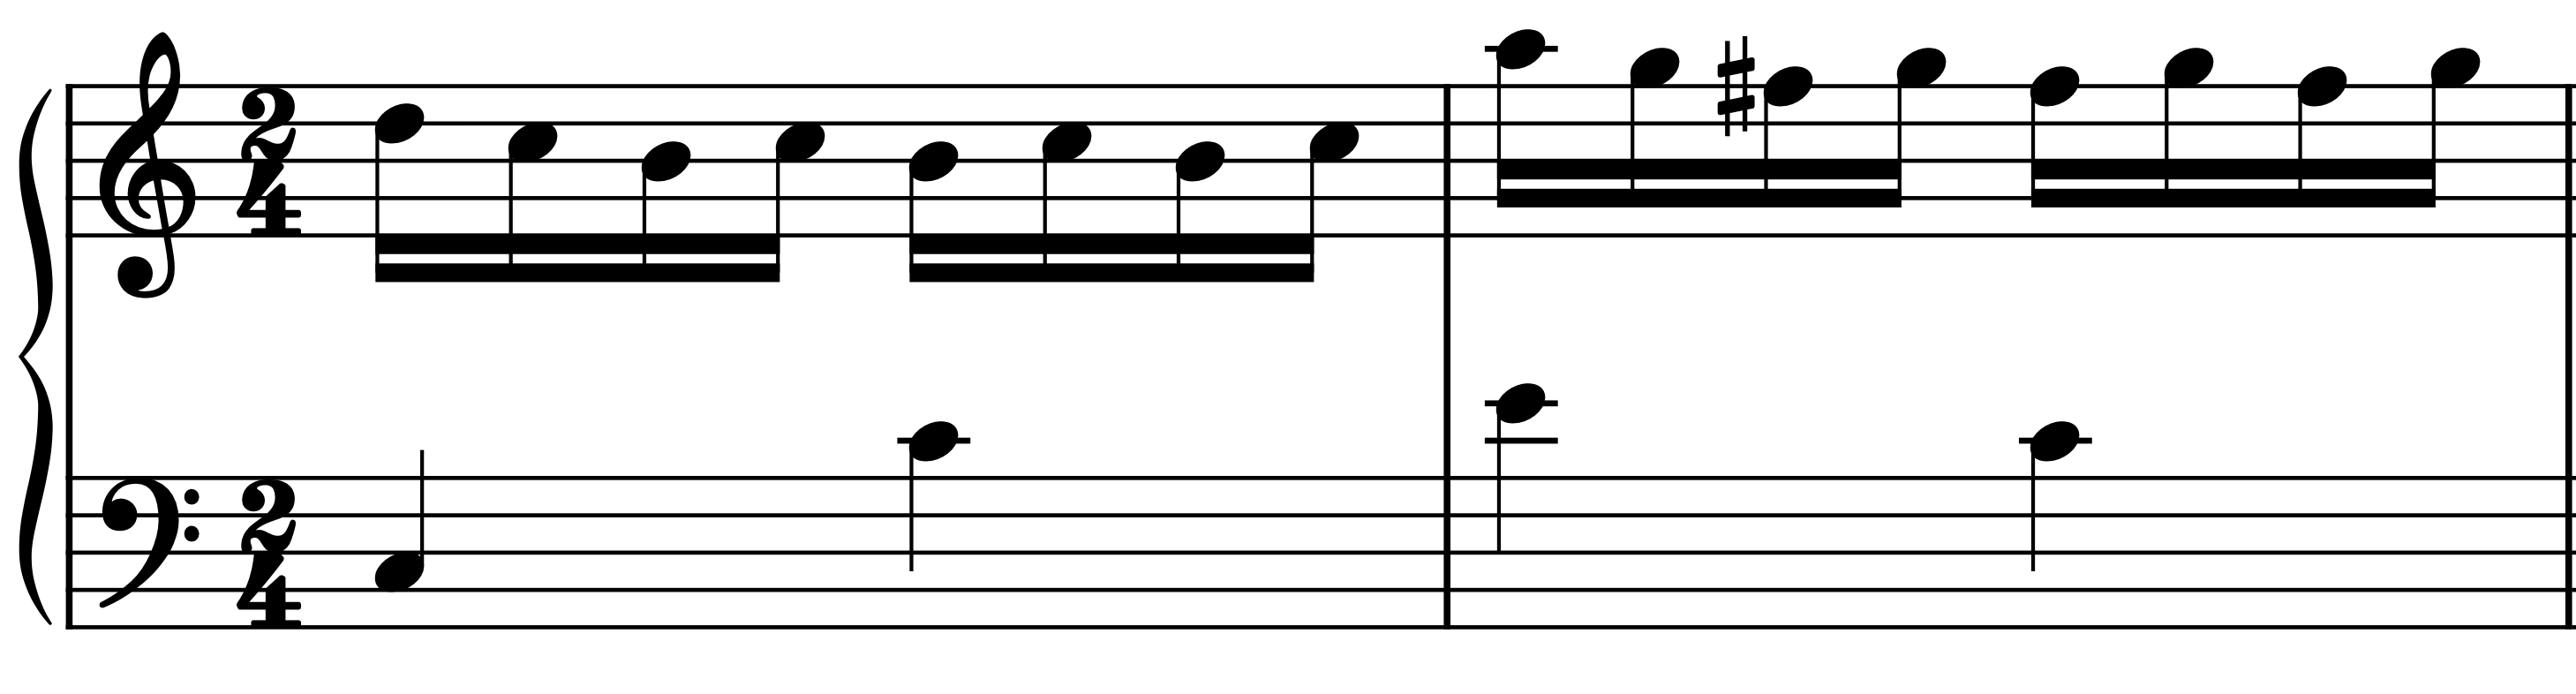

In [43]:
print(f"Below is the short score snippet again, along with the MIDI snippet (first 2 measures).")
display(Image(filename=str(PREVIEW_IMAGE), width=700))
perf = pt.load_performance_midi(str(MIDI_SNIPPET_FILE))
perf_audio = pt.utils.synthesize(perf)
sr = pt.utils.globals.SAMPLE_RATE
display(Audio(perf_audio, rate=sr))

# Cached once: score image + its aspect ratio (used for figure sizing below).
SCORE_IMG = mpimg.imread(str(PREVIEW_IMAGE))
SCORE_AR = SCORE_IMG.shape[1] / SCORE_IMG.shape[0]

## Now, let's visualize the output of these processors as a comparison to the audio processors that we have already seen.
#### First let's select the score follower that we would like to work with:

## Select Score Follower from the dropdown menu in the cell below:

**Particle Filter:**
In this notebook, the Particle Filter uses the PitchClassPianoRollProcessor

**Outer Product HMM:**
The Outer Product HMM uses the ChordOnsetProcessor

In [44]:
from ipywidgets import Dropdown
from IPython.display import display

method = 'outerhmm'  # Default method

# Interactive model selection
model_dropdown = Dropdown(
    options={'Particle Filter': 'pf', 'Outer Product HMM': 'outerhmm'},
    value='outerhmm',
    description='Model:'
)

# Handle selection
def on_model_change(change):
    global method
    method = change['new']
    print(f"Selected method: {method}")

model_dropdown.observe(on_model_change, names='value')
display(model_dropdown)

Dropdown(description='Model:', index=1, options={'Particle Filter': 'pf', 'Outer Product HMM': 'outerhmm'}, va…

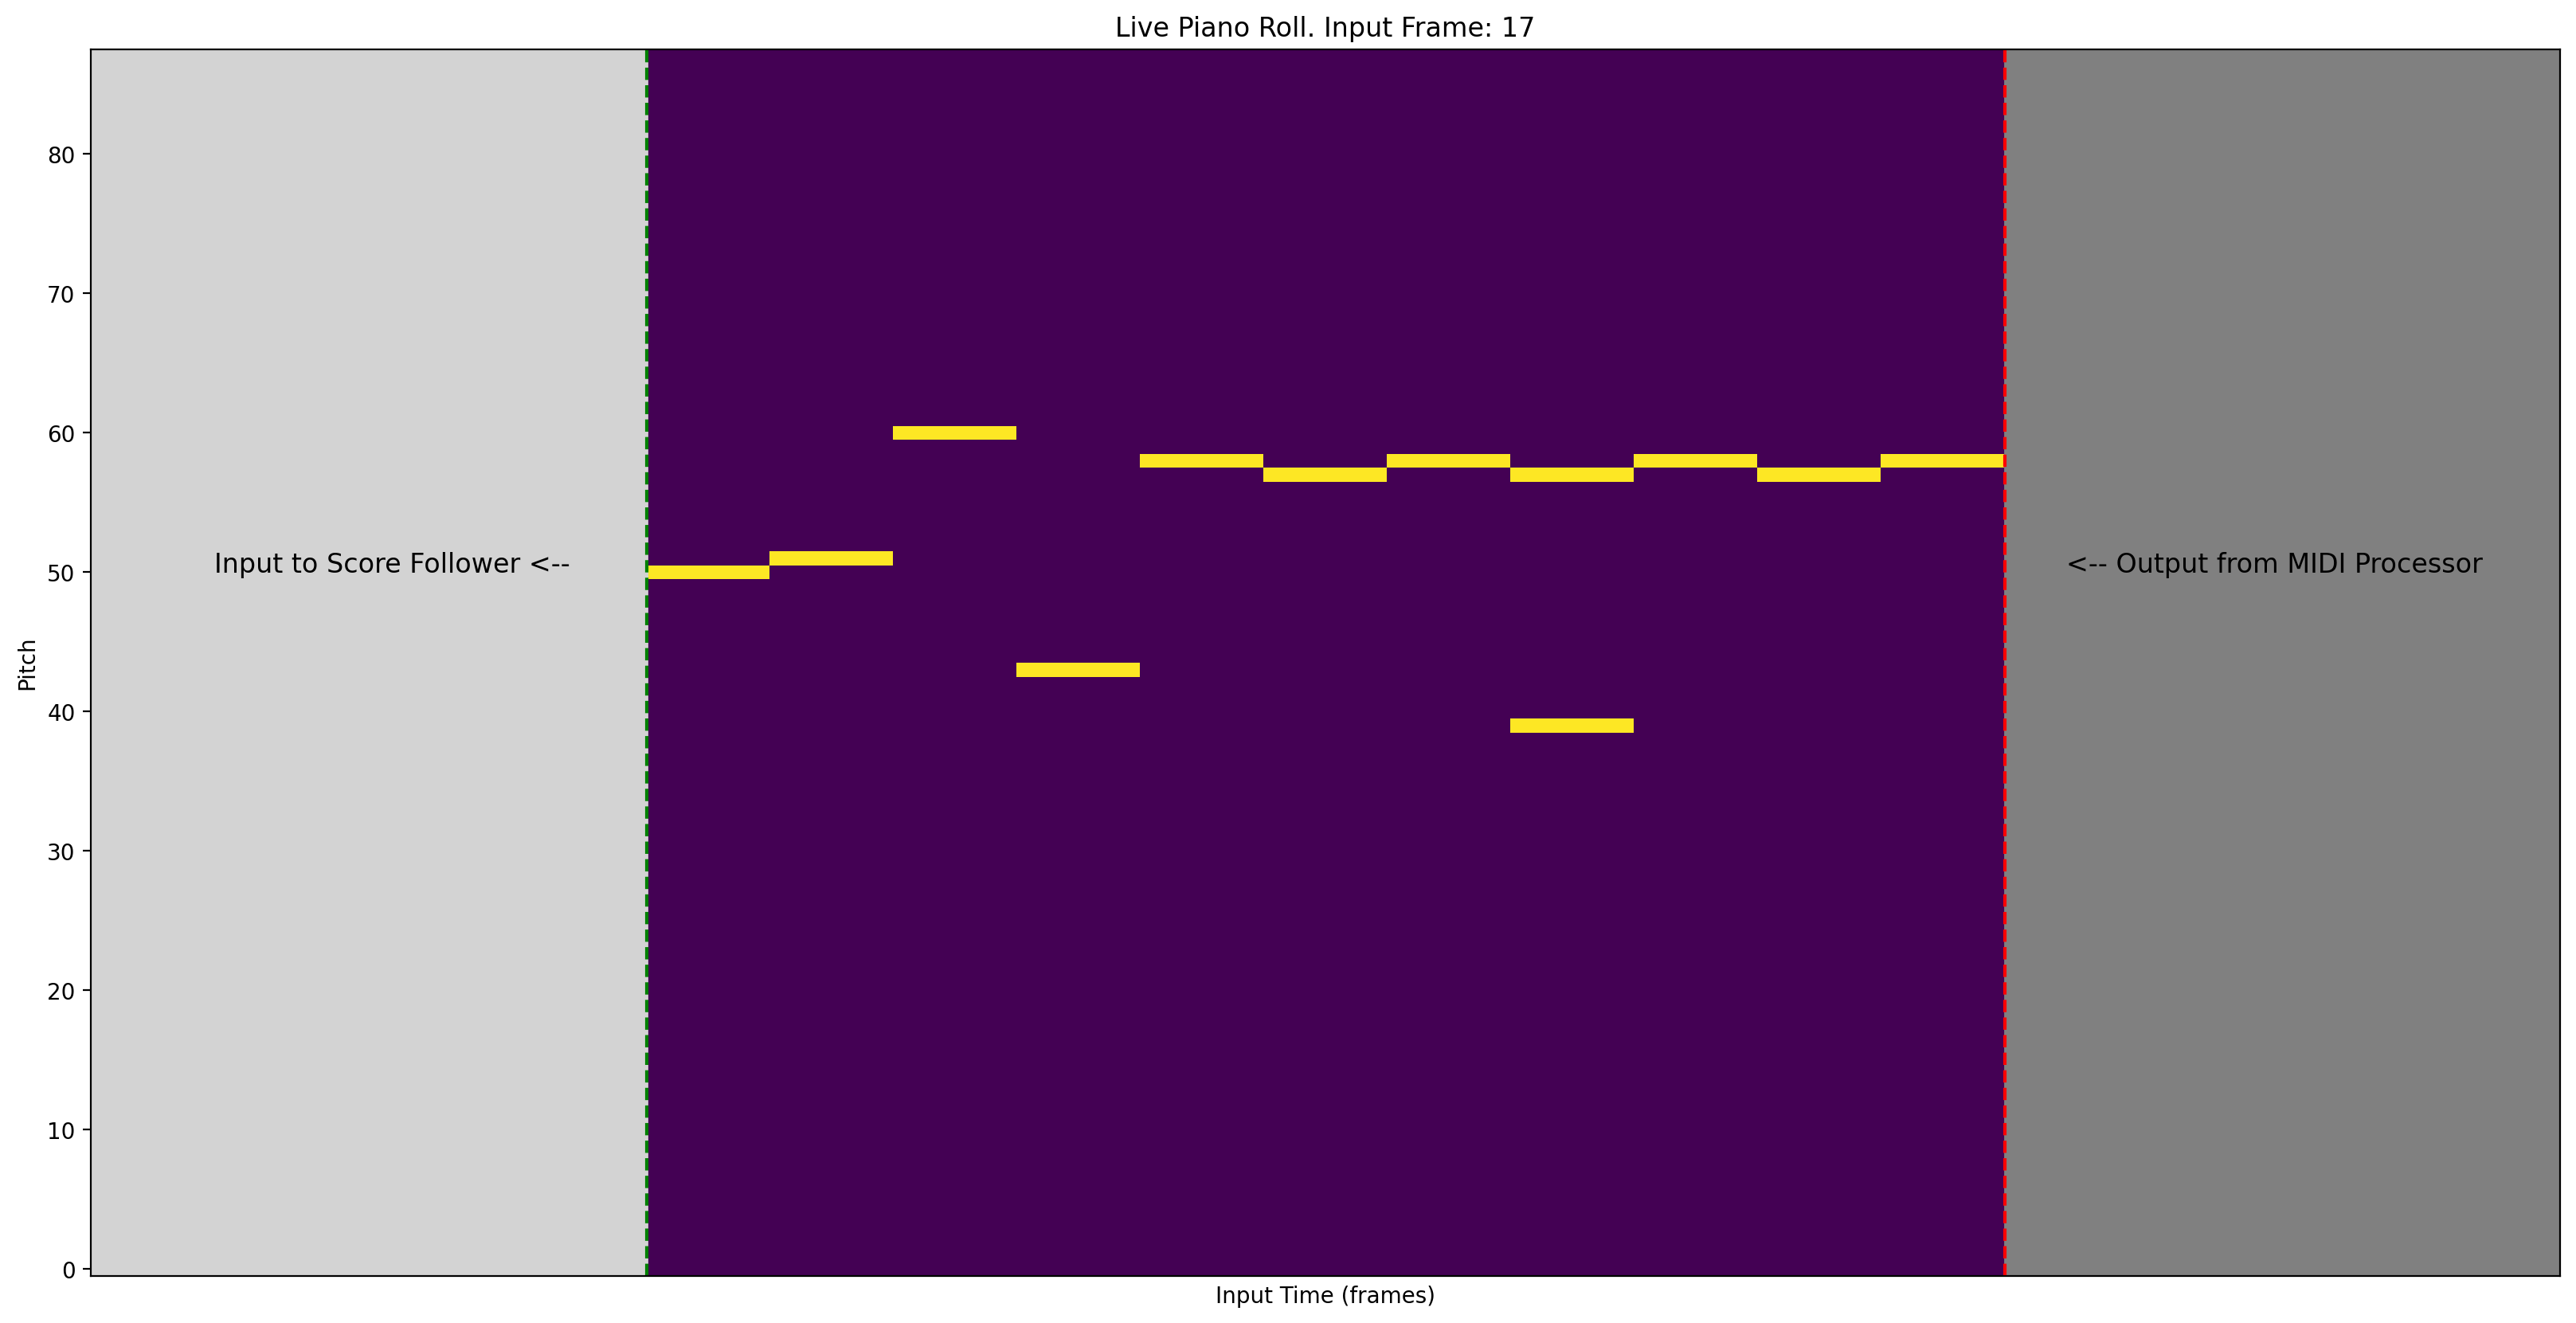

* Stop listening to MIDI stream....


In [45]:
'''Uncomment the line below to manually set the method without using the dropdown.'''
#method = 'outerhmm' # 'pf'

matchmaker = mm.Matchmaker(
    score_file=SNIPPET_SCORE_FILE,
    performance_file=MIDI_SNIPPET_FILE,
    input_type="midi",
    method=method,
)

sf = matchmaker.score_follower

if method == 'outerhmm':
    pianoroll = np.zeros((88, 20))
    frame_skip = 1
elif method == 'pf':
    pianoroll = np.zeros((12, 20))
    frame_skip = 5

pianoroll_cursor_end_point = pianoroll.shape[1] * 3 // 4
pianoroll_cursor_start_point = pianoroll.shape[1] * 1 // 4
def update_pianoroll(pianoroll, feature):
    pianoroll[:, :-1] = pianoroll[:, 1:]
    pianoroll[:, pianoroll_cursor_end_point] = feature

    return pianoroll

fig_y = 10
fig_x = 20

fig_text = 5 if method == 'pf' else 50

fig, ax = plt.subplots(ncols=1, figsize=(fig_x, fig_y))
count = 1



with matchmaker.stream:
    while sf.is_still_following():
        features = sf.queue.get(timeout=QUEUE_TIMEOUT)
        if features is STREAM_END:
            break
        beat = sf(features[0], features[1])
        pianoroll = update_pianoroll(pianoroll, features[0])

        if count % frame_skip == 0 or count == 1:  # Update the plot every 5 frames
            ax.clear()

            ax.imshow(pianoroll, aspect='auto', origin='lower')
            ax.set_title("Live Piano Roll. Input Frame: {}".format(count))
            ax.set_xticks([])
            # add a vertical line at the cursor point
            ax.axvline(x=pianoroll_cursor_end_point+0.5, color='r', linestyle='--')
            ax.axvline(x=pianoroll_cursor_start_point-0.5, color='g', linestyle='--')
            # colour the background of the plot to the right of the cursor point till the end of the image in grey
            ax.axvspan(pianoroll_cursor_end_point+0.5, pianoroll.shape[1], color='grey')
            ax.axvspan(0, pianoroll_cursor_start_point-0.5, color='lightgrey')
            ax.set_xlim(0, pianoroll.shape[1])
            # add text to the right of the cursor point saying "MIDI Stream Processor"
            ax.text(pianoroll_cursor_end_point+1, fig_text, "<-- Output from MIDI Processor", fontsize=12)
            ax.text(1, fig_text, "Input to Score Follower <--", fontsize=12)
            ax.set_xlabel("Input Time (frames)")
            ax.set_ylabel("Pitch")

            clear_output(wait=True)
            display(fig)                

        count += 1

ax.clear()
clear_output(wait=True)
plt.close()



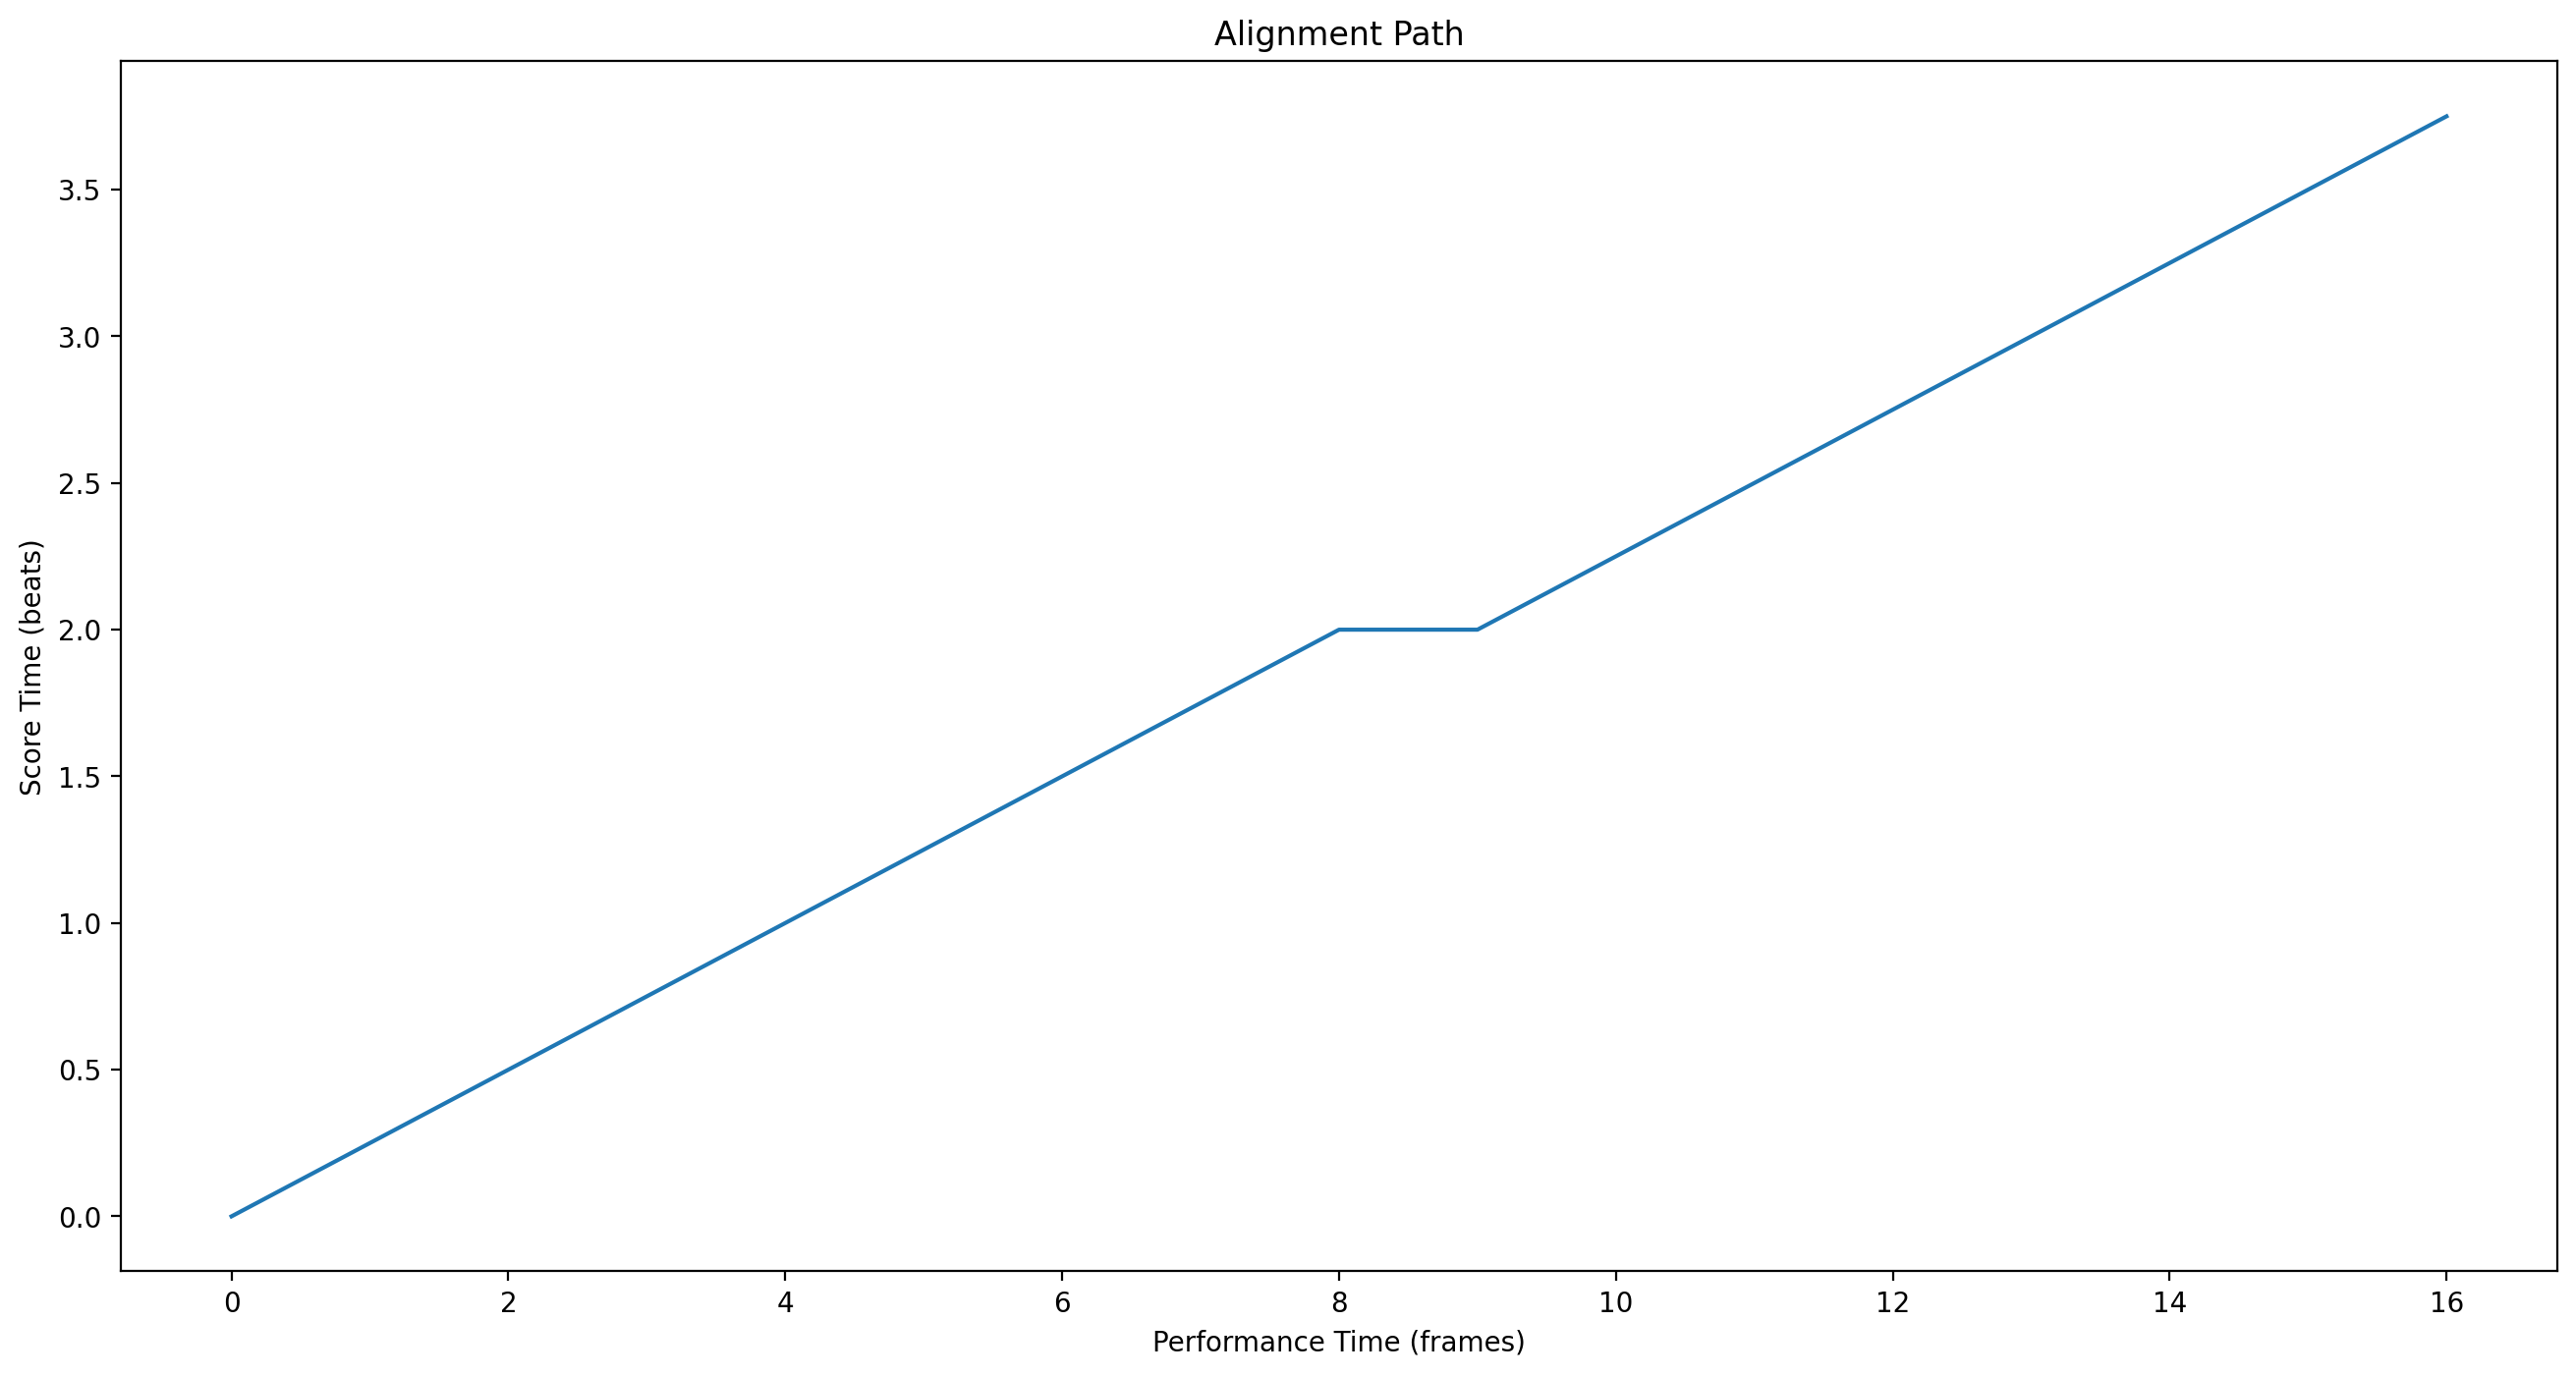

In [46]:
plt.figure(figsize=(16, 8))
plt.plot([x[0] for x in sf._alignment_path])
plt.xlabel("Performance Time (frames)")
plt.ylabel("Score Time (beats)")
plt.title("Alignment Path")
plt.show()

## 3. Matchmaker overview

For this workshop, the main object is `Matchmaker`. We use it in **simulation mode**: the input is a recorded audio or MIDI performance file, but Matchmaker feeds it through the same streaming pipeline used for real-time score following.

```python
from matchmaker import Matchmaker

mm = Matchmaker(
    score_file="path/to/score.musicxml",
    performance_file="path/to/performance.mp3",  # or .mid
    input_type="audio",                          # or "midi"
    method="arzt",                              # optional
)

for current_position in mm.run():
    print(current_position)
```

The yielded value is the estimated score position in beats. After a run, `mm.score_follower.alignment_path` stores a `(2, T)` array:

- row 0: estimated score beat
- row 1: performance time in seconds

We will use the helper functions below so that each practical example returns the same kind of result dictionary.

In [60]:
print("Available methods:")
for input_type, methods in AVAILABLE_METHODS.items():
    print(f"  {input_type}: {methods}")

print("\nDefaults:")
print("  method:", DEFAULT_METHOD)
print("  processor:", DEFAULT_PROCESSOR)

Available methods:
  audio: ['arzt', 'dixon', 'outerhmm', 'skf', 'pf']
  midi: ['arzt', 'dixon', 'hmm', 'pthmm', 'outerhmm', 'pf', 'OPTM', 'OTM', 'SLT_OLTW', 'SL_OLTW']

Defaults:
  method: {'audio': 'arzt', 'midi': 'pthmm'}
  processor: {'audio': 'chroma', 'midi': 'pitch'}


### 3.1 Reading Matchmaker's score positions

Matchmaker reports the current position in **score beats**. For this Mozart example, the score positions come from Partitura's `note_array()` representation, especially the `onset_beat` field.

The unique note-onset beats become the main discrete score states used by several online followers.

Number of notes: 218
Number of unique score onset positions: 167
First 8 score positions in beats (first measure):
[0.   0.25 0.5  0.75 1.   1.25 1.5  1.75]


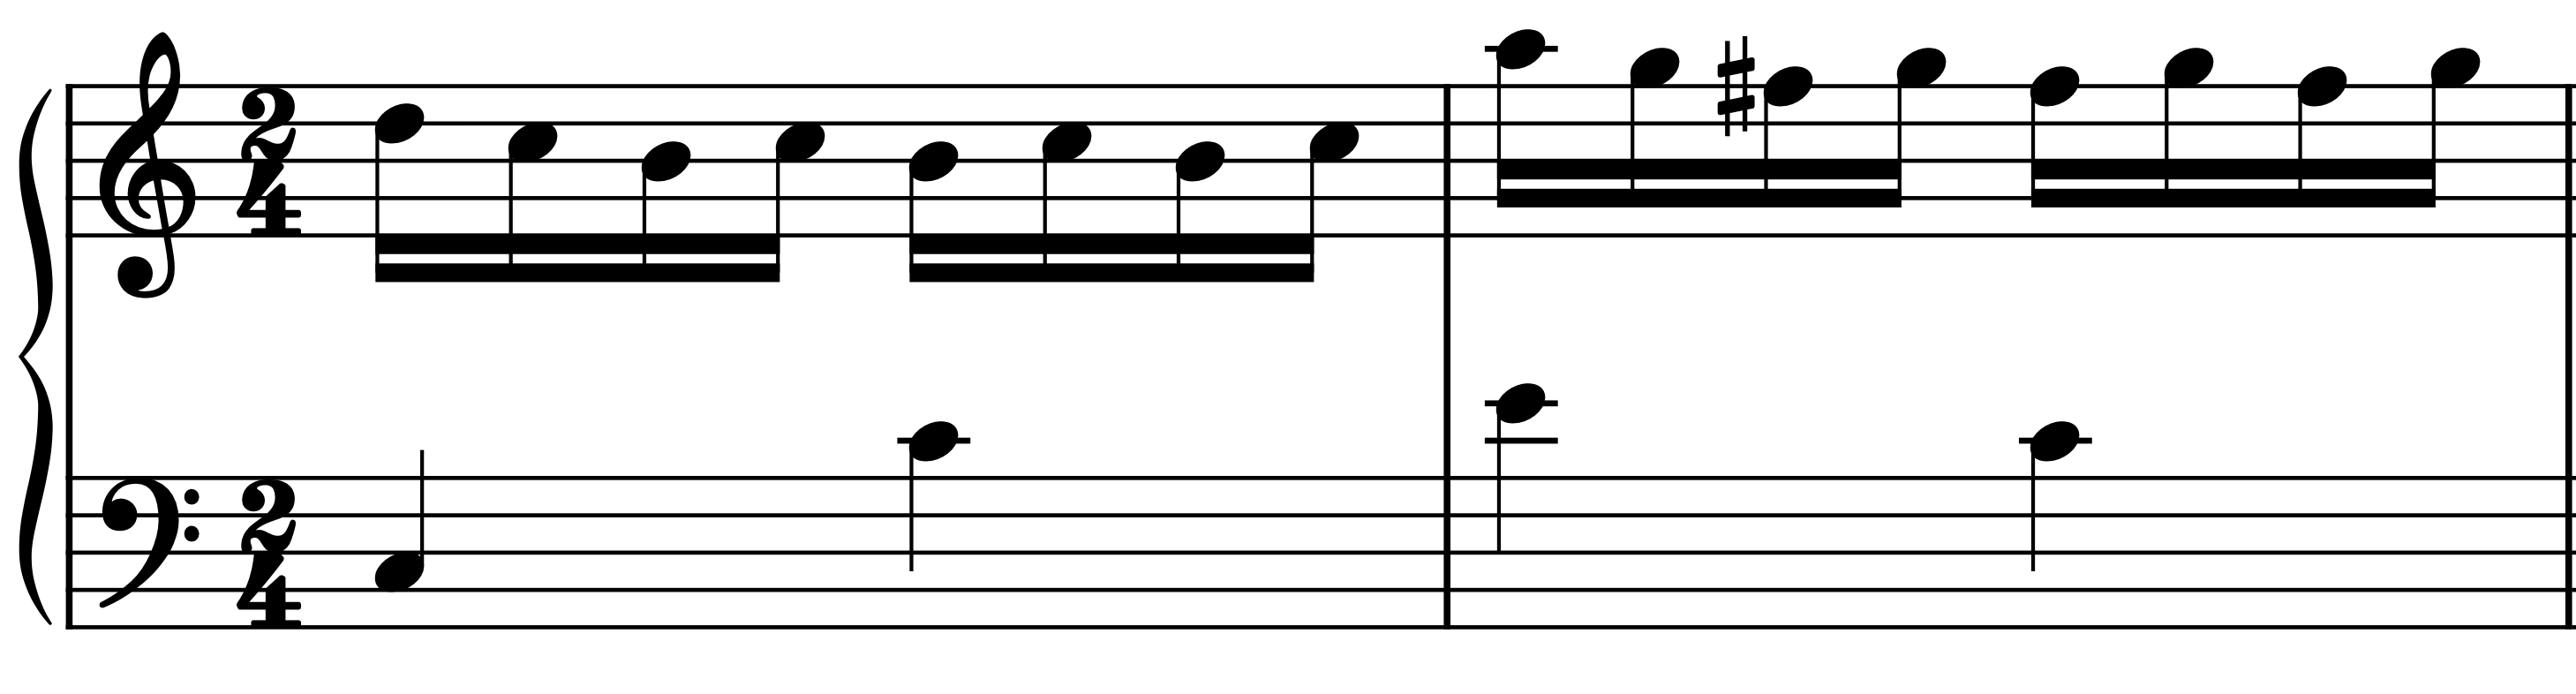

,id,pitch,onset_beat,duration_beat
0,n9,48,0.00,1.00
1,n1,74,0.00,0.25
2,n2,72,0.25,0.25
3,n3,71,0.50,0.25
4,n4,72,0.75,0.25
5,n10,60,1.00,1.00
6,n5,71,1.00,0.25
7,n6,72,1.25,0.25
8,n7,71,1.50,0.25
9,n8,72,1.75,0.25


In [61]:
score = pt.load_musicxml(str(SCORE_FILE))
score_part = score[0]
note_array = score_part.note_array()
score_positions = np.unique(note_array["onset_beat"])

print(f"Number of notes: {len(note_array)}")
print(f"Number of unique score onset positions: {len(score_positions)}")
print("First 8 score positions in beats (first measure):")
print(score_positions[:8])

display(Image(filename=str(PREVIEW_IMAGE), width=700))

pd.DataFrame(note_array[:10])[["id", "pitch", "onset_beat", "duration_beat"]]

In [67]:
plt.rcParams["figure.figsize"] = (10, 4)
plt.rcParams["axes.grid"] = True

RESULTS_DIR = Path("results")
RESULTS_DIR.mkdir(exist_ok=True)

print(f"Results will be saved in {RESULTS_DIR.resolve()}")


Results will be saved in /home/suhit/JKU/Repos/mec2026_alignment_workshop/notebooks/results


## 5. MIDI score following

For MIDI input, the observations are symbolic note events rather than audio frames. This changes the feature representation and the error model.

MIDI methods available in Matchmaker include:

- `"pthmm"`: pitch-based HMM score follower. This is the default for MIDI.
- `"hmm"`: HMM using pitch and inter-onset information.
- `"outerhmm"`: outer-product HMM for symbolic input.
- `"arzt"` and `"dixon"`: event-based online time warping variants.

The default MIDI processor is `"pitch_chord"`, which groups near-simultaneous note events into chord observations.

Number of performed MIDI notes: 219
Performance note-array fields: ('onset_sec', 'duration_sec', 'onset_tick', 'duration_tick', 'pitch', 'velocity', 'track', 'channel', 'id')


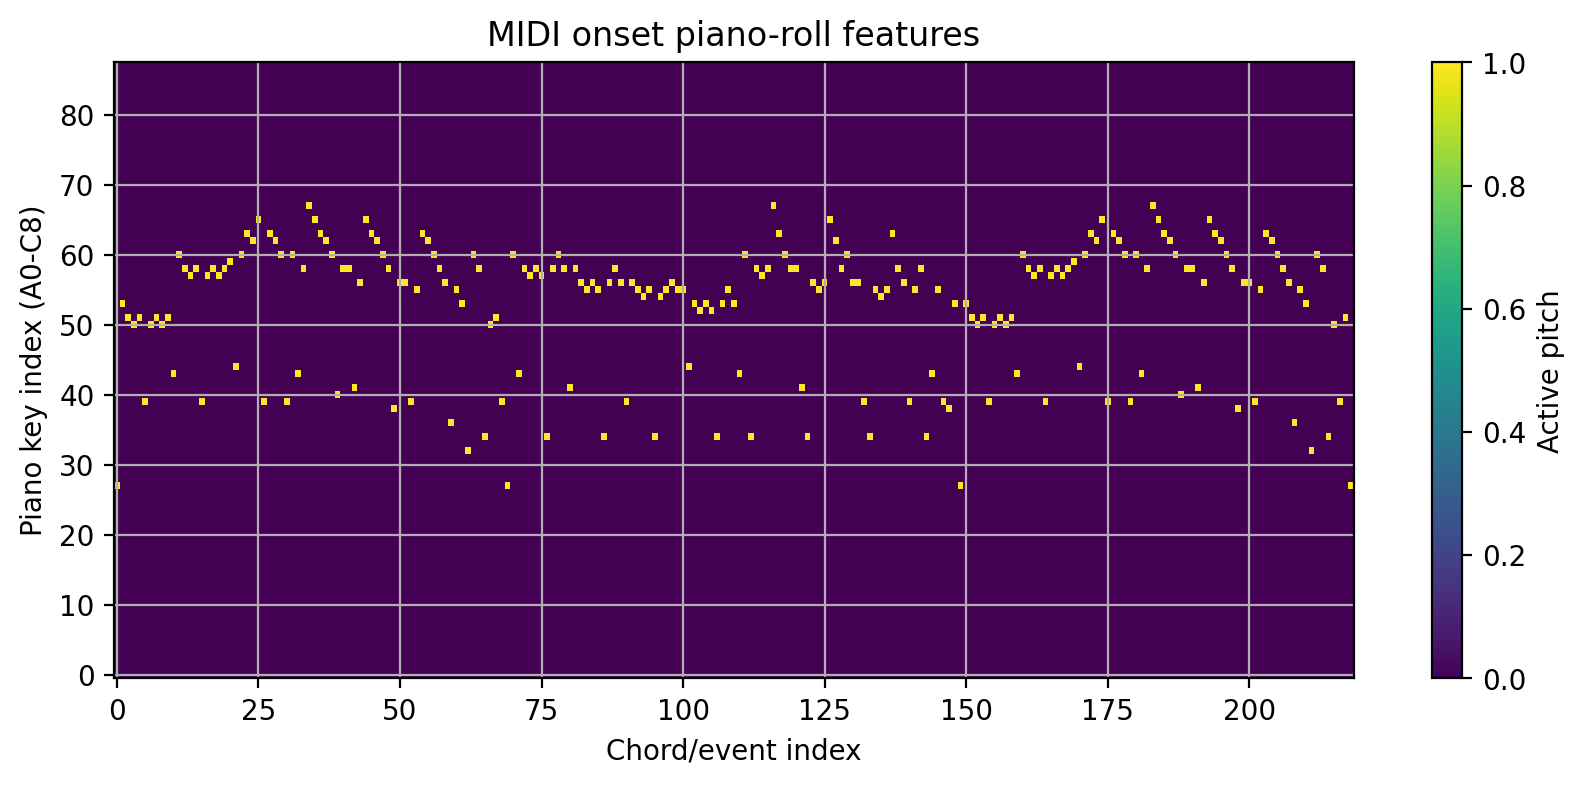

,pitch,onset_sec,duration_sec
0,48,0.022917,0.063542
1,74,0.025000,0.077083
2,72,0.137500,0.086458
3,71,0.247917,0.056250
4,72,0.340625,0.094792
5,60,0.446875,0.081250
6,71,0.455208,0.061458
7,72,0.580208,0.037500
8,71,0.653125,0.102083
9,72,0.753125,0.089583


In [63]:
performance = pt.load_performance_midi(str(MIDI_FILE))
performance_notes = performance.note_array()

print("Number of performed MIDI notes:", len(performance_notes))
print("Performance note-array fields:", performance_notes.dtype.names)

midi_pianoroll, midi_onsets = onset_pianoroll(
    performance_notes,
    onset_key="onset_sec",
    piano_range=True,
)

fig, ax = plt.subplots(figsize=(10, 4))
img = ax.imshow(midi_pianoroll.T, origin="lower", aspect="auto", interpolation="nearest")
ax.set_xlabel("Chord/event index")
ax.set_ylabel("Piano key index (A0-C8)")
ax.set_title("MIDI onset piano-roll features")
fig.colorbar(img, ax=ax, label="Active pitch")
plt.show()

pd.DataFrame(performance_notes[:10])[["pitch", "onset_sec", "duration_sec"]]

### 5.1 PitchHMM

`pthmm` is the default MIDI method. It uses pitch observations and a probabilistic state model to estimate which score onset is currently active.

Performance file: short1.mid, with input mode: midi
Running Matchmaker with score file (short.musicxml) and method 'pthmm'...
* Mock listening to stream....


/home/suhit/miniconda3/envs/matchmaker/lib/python3.12/site-packages/hiddenmarkov/__init__.py:612: RuntimeWarning: divide by zero encountered in log
  self._log_transition_prob = np.log(self._transition_prob)
/home/suhit/miniconda3/envs/matchmaker/lib/python3.12/site-packages/hiddenmarkov/__init__.py:600: RuntimeWarning: divide by zero encountered in log
  self._log_init_dist = np.log(self._init_dist)


* Stop listening to MIDI stream....
MIDI observations: 210
Alignment path shape: (2, 210)
First 10 estimated beat positions:
[0.   0.25 0.5  0.75 1.   1.   1.25 1.5  1.75 2.  ]
Evaluation result:
{
  "beat": {
    "mean": 5.36,
    "median": 5.5,
    "std": 3.1176,
    "skewness": -0.024,
    "kurtosis": -1.1695,
    "0.05b": 0.006,
    "0.1b": 0.006,
    "0.3b": 0.0299,
    "0.5b": 0.0539,
    "1b": 0.1138,
    "2b": 0.2335
  },
  "ms": {
    "mean": 2522.5075,
    "median": 2564.0628,
    "std": 1499.4101,
    "skewness": 0.0052,
    "kurtosis": -1.2084,
    "50ms": 0.0048,
    "100ms": 0.0095,
    "300ms": 0.0619,
    "500ms": 0.1238,
    "1000ms": 0.2286,
    "2000ms": 0.3571
  },
  "rtf": 0.0144
}


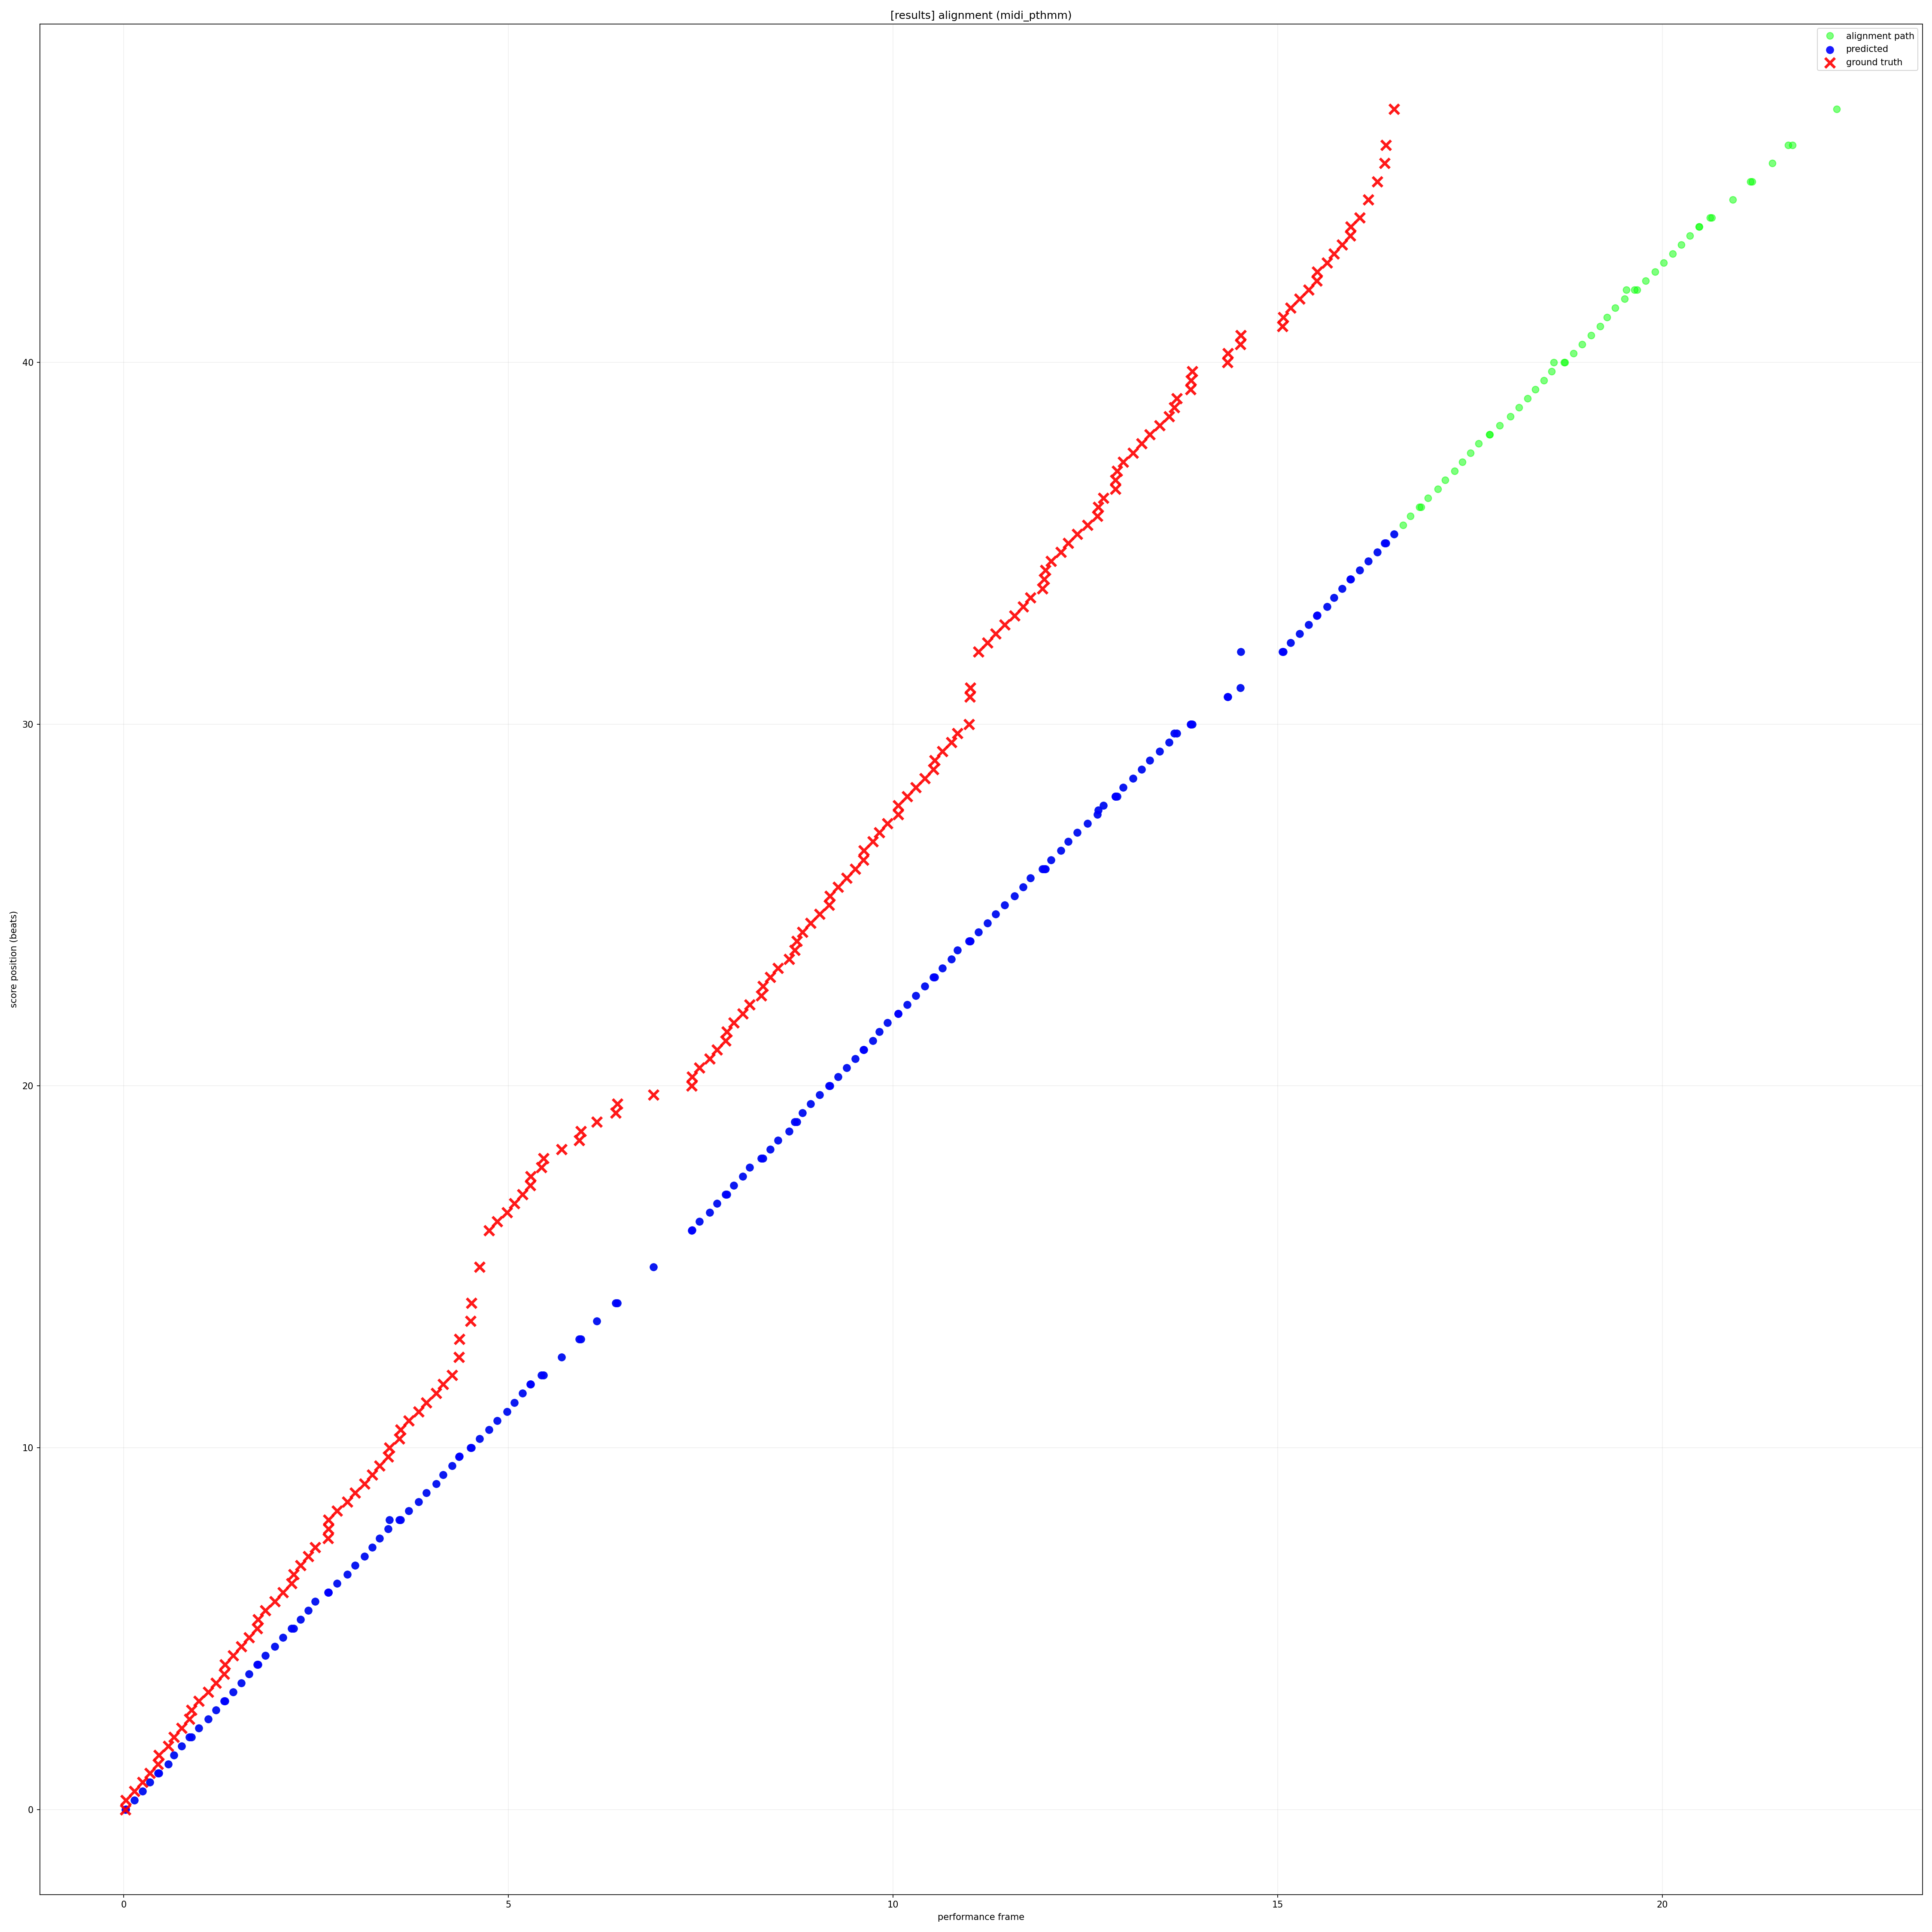

In [64]:
print(f"Performance file: {MIDI_FILE.name}, with input mode: midi")
print(f"Running Matchmaker with score file ({SCORE_FILE.name}) and method 'pthmm'...")

midi_pthmm_mm = Matchmaker(
    score_file=SCORE_FILE,
    performance_file=MIDI_FILE,
    input_type="midi",
    method="pthmm",
)

midi_pthmm_positions = []
for current_position in midi_pthmm_mm.run(verbose=False):
    midi_pthmm_positions.append(float(current_position))

midi_pthmm_path = midi_pthmm_mm.score_follower.alignment_path

print("MIDI observations:", len(midi_pthmm_positions))
print("Alignment path shape:", midi_pthmm_path.shape)
print("First 10 estimated beat positions:")
print(np.round(midi_pthmm_positions[:10], 3))

midi_pthmm_eval = midi_pthmm_mm.run_evaluation(
    perf_annotations=NOTE_ANNOTATIONS,
    debug=True,
    save_dir=RESULTS_DIR,
    run_name="midi_pthmm",
    level="note",
    plot_dist_matrix=False,
)

print("Evaluation result:")
print(json.dumps(midi_pthmm_eval, indent=2))
display(Image(filename=str(RESULTS_DIR / "midi_pthmm.png"), width=700))

### 5.2 OuterHMM

Now run the symbolic OuterHMM separately. Keeping this plot separate from PitchHMM makes it easier to inspect the path shape and any failures.

Performance file: short1.mid, with input mode: midi
Running Matchmaker with score file (short.musicxml) and method 'outerhmm'...
* Mock listening to stream....
* Stop listening to MIDI stream....
MIDI OuterHMM observations: 169
Alignment path shape: (2, 338)
First 10 estimated beat positions:
[0.   0.25 0.5  0.75 1.   1.25 1.5  1.75 2.   2.25]
Evaluation result:
{
  "beat": {
    "mean": 5.3683,
    "median": 5.5,
    "std": 3.1249,
    "skewness": -0.0196,
    "kurtosis": -1.1689,
    "0.05b": 0.006,
    "0.1b": 0.006,
    "0.3b": 0.0299,
    "0.5b": 0.0539,
    "1b": 0.1138,
    "2b": 0.2335
  },
  "ms": {
    "mean": 2518.2939,
    "median": 2535.4165,
    "std": 1517.3085,
    "skewness": -0.013,
    "kurtosis": -1.2139,
    "50ms": 0.0059,
    "100ms": 0.0118,
    "300ms": 0.0651,
    "500ms": 0.1243,
    "1000ms": 0.2367,
    "2000ms": 0.355
  },
  "rtf": 0.0085
}


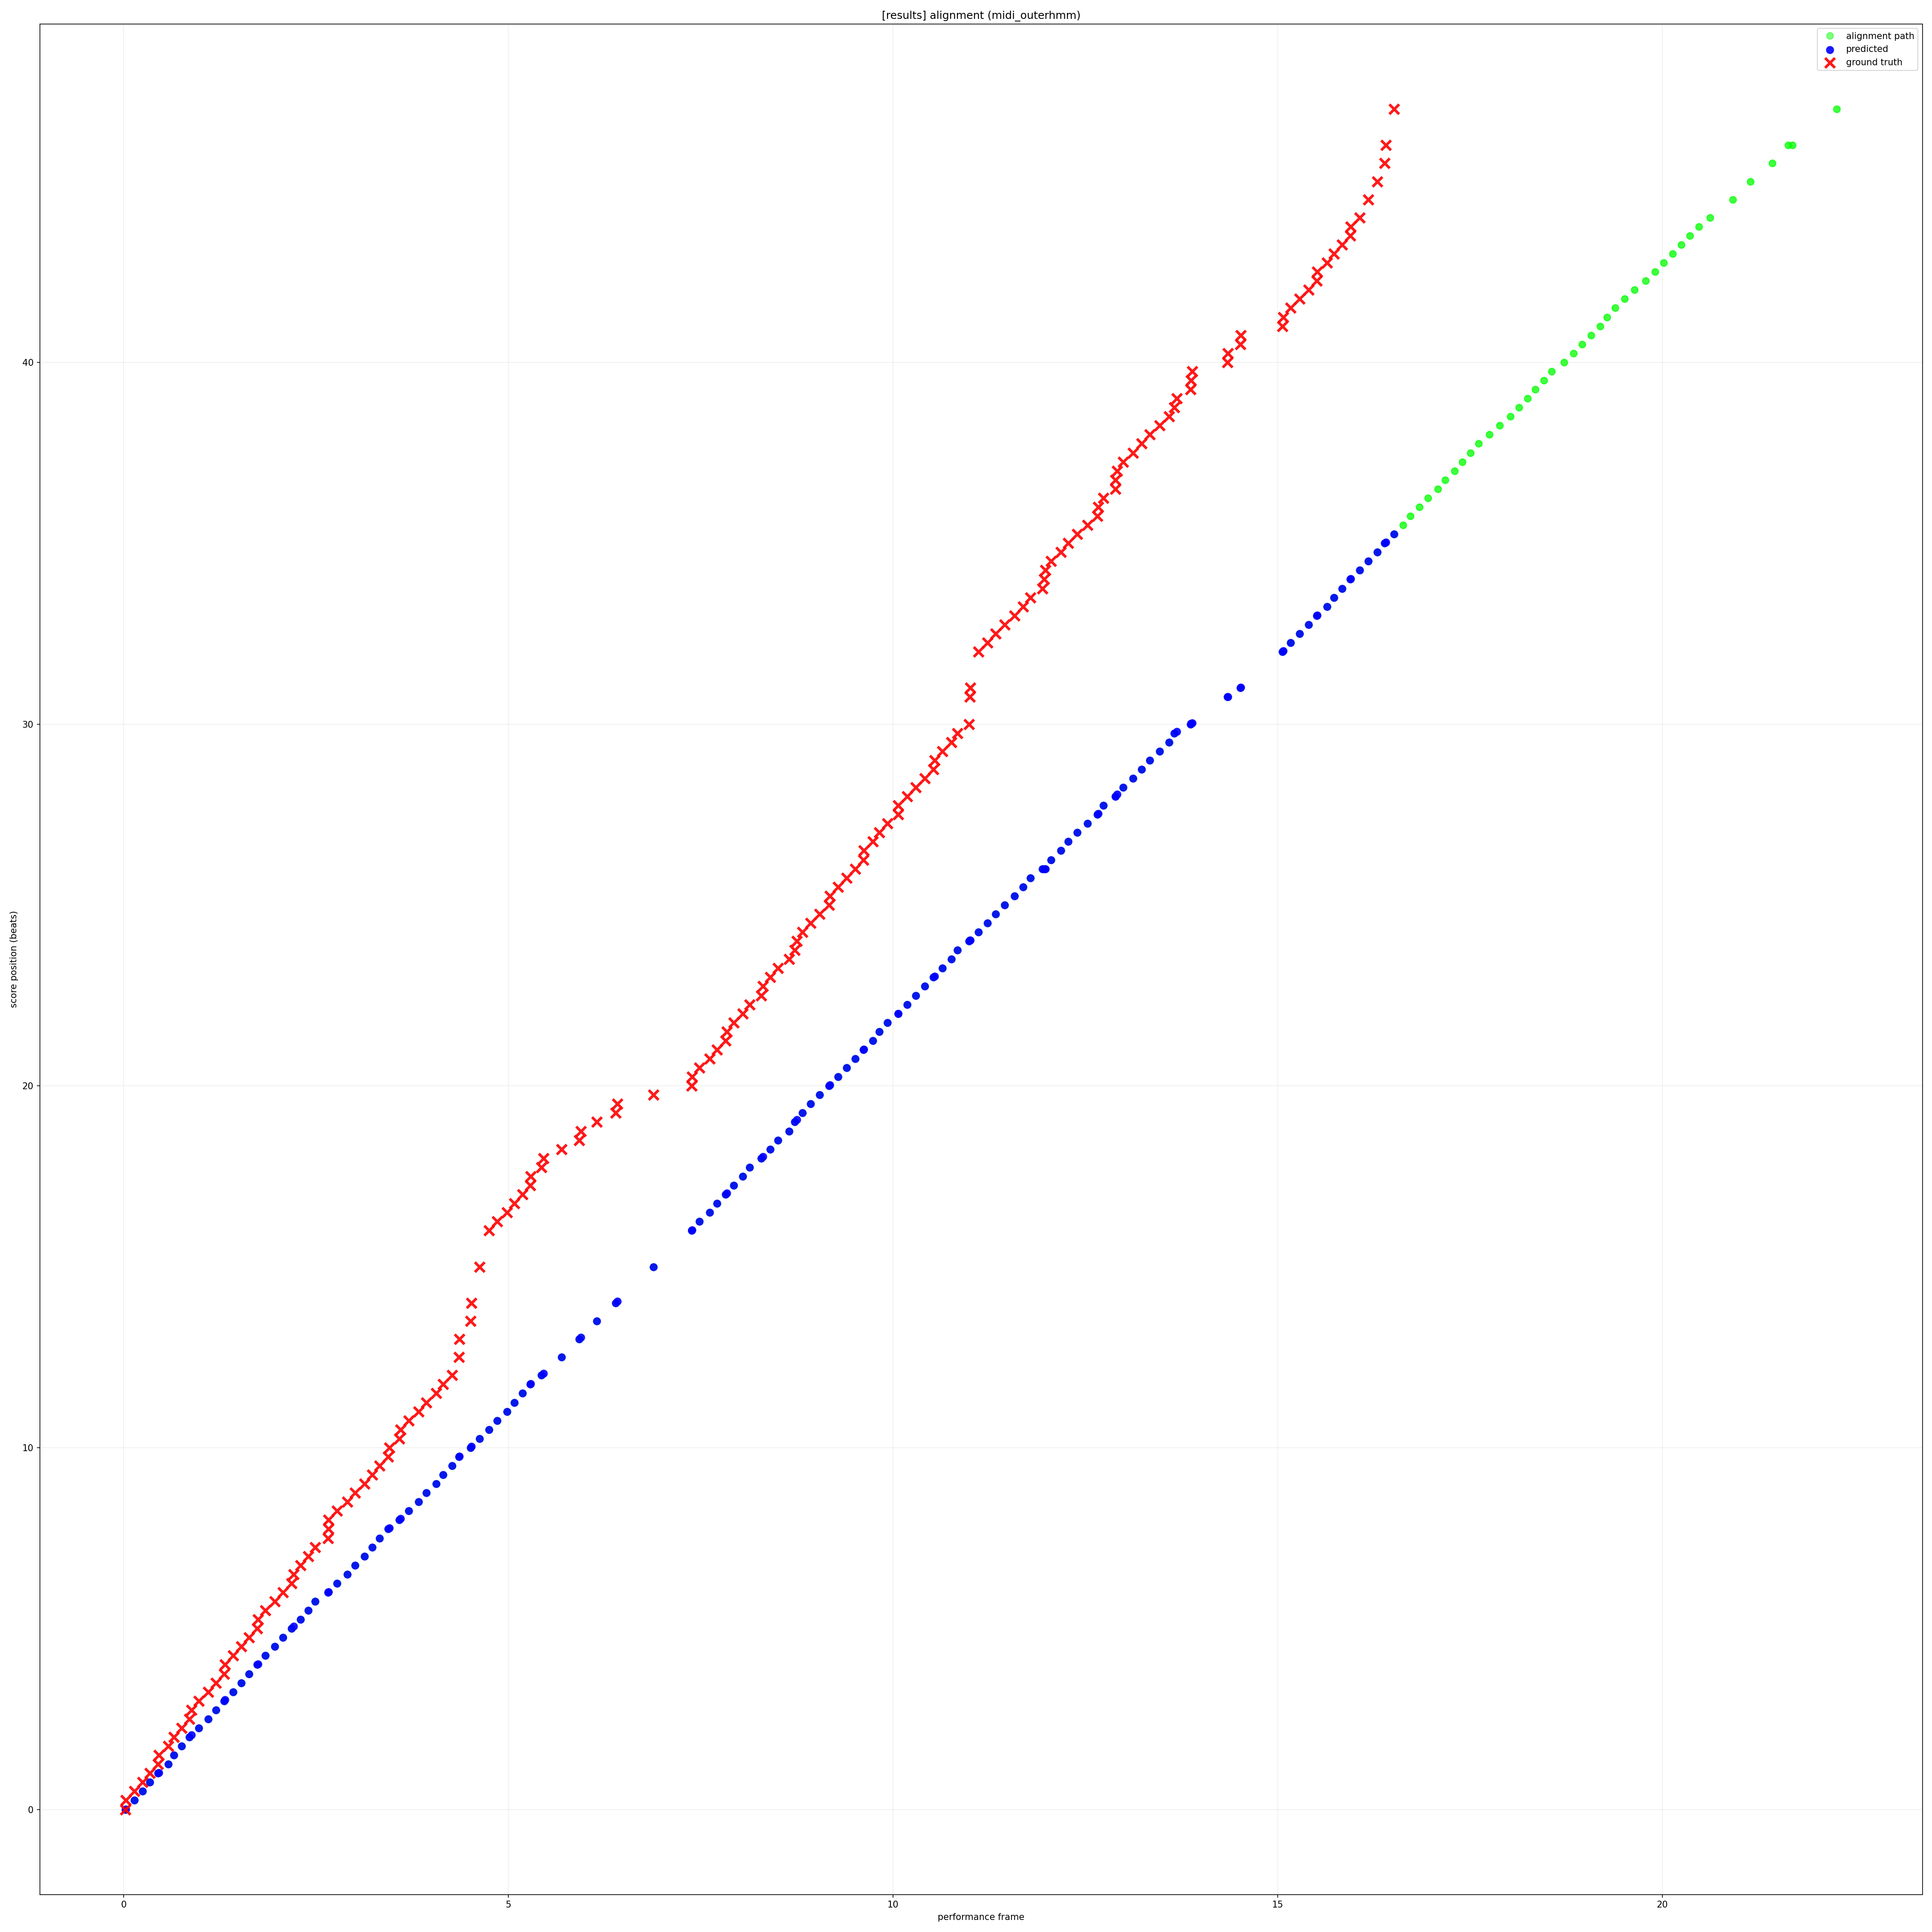

In [65]:
midi_outerhmm_mm = None
midi_outerhmm_positions = []
midi_outerhmm_path = None
midi_outerhmm_eval = None

try:
    print(f"Performance file: {MIDI_FILE.name}, with input mode: midi")
    print(f"Running Matchmaker with score file ({SCORE_FILE.name}) and method 'outerhmm'...")

    midi_outerhmm_mm = Matchmaker(
        score_file=SCORE_FILE,
        performance_file=MIDI_FILE,
        input_type="midi",
        method="outerhmm",
    )

    for current_position in midi_outerhmm_mm.run(verbose=False):
        midi_outerhmm_positions.append(float(current_position))

    midi_outerhmm_path = midi_outerhmm_mm.score_follower.alignment_path

    print("MIDI OuterHMM observations:", len(midi_outerhmm_positions))
    print("Alignment path shape:", midi_outerhmm_path.shape)
    print("First 10 estimated beat positions:")
    print(np.round(midi_outerhmm_positions[:10], 3))

    midi_outerhmm_eval = midi_outerhmm_mm.run_evaluation(
        perf_annotations=NOTE_ANNOTATIONS,
        debug=True,
        save_dir=RESULTS_DIR,
        run_name="midi_outerhmm",
        level="note",
        plot_dist_matrix=False,
    )

    print("Evaluation result:")
    print(json.dumps(midi_outerhmm_eval, indent=2))
    display(Image(filename=str(RESULTS_DIR / "midi_outerhmm.png"), width=700))
except Exception as exc:
    print("MIDI OuterHMM demo skipped:")
    print(type(exc).__name__, exc)

## 6. MIDI evaluation

Compare the MIDI PitchHMM and MIDI OuterHMM evaluation metrics in one table.

In [66]:
midi_eval_items = [
    ("midi pthmm", len(midi_pthmm_positions), midi_pthmm_eval),
]

if midi_outerhmm_eval is not None:
    midi_eval_items.append(
        ("midi outerhmm", len(midi_outerhmm_positions), midi_outerhmm_eval)
    )

midi_eval_rows = []
for method, observations, evaluation in midi_eval_items:
    row = {"method": method, "observations": observations}
    for key, value in evaluation.items():
        if isinstance(value, dict):
            for subkey, subvalue in value.items():
                row[f"{key}.{subkey}"] = subvalue
        else:
            row[key] = value
    midi_eval_rows.append(row)

pd.DataFrame(midi_eval_rows)

,method,observations,beat.mean,beat.median,beat.std,beat.skewness,beat.kurtosis,beat.0.05b,beat.0.1b,beat.0.3b,...,ms.std,ms.skewness,ms.kurtosis,ms.50ms,ms.100ms,ms.300ms,ms.500ms,ms.1000ms,ms.2000ms,rtf
0,midi pthmm,210,5.3600,5.5,3.1176,-0.0240,-1.1695,0.006,0.006,0.0299,...,1499.4101,0.0052,-1.2084,0.0048,0.0095,0.0619,0.1238,0.2286,0.3571,0.0144
1,midi outerhmm,169,5.3683,5.5,3.1249,-0.0196,-1.1689,0.006,0.006,0.0299,...,1517.3085,-0.0130,-1.2139,0.0059,0.0118,0.0651,0.1243,0.2367,0.3550,0.0085


## 7. Practical variations

Small changes to try during the workshop:

Audio:

- Change the audio method from `"arzt"` to `"dixon"`.
- Change the audio processor from `"chroma"` to `"mfcc"`, `"cqt"`, or `"mel"`.
- Inspect the saved files in `results/`: alignment path TSV, ground-truth TSV, JSON metrics, and debug plot.

MIDI:

- Try MIDI `"hmm"` or `"arzt"` in the playground cell and inspect each plot separately.
- Look for places where symbolic methods react differently to event grouping or pitch errors.

The important thing to watch is not only whether a final alignment looks correct, but how quickly and stably the online estimate moves while the performance unfolds.

In [ ]:
# Example playground cell.
# Edit these values and rerun.

PLAY_INPUT_TYPE = "audio"   # "audio" or "midi"
PLAY_METHOD = "dixon"       # audio: "arzt", "dixon", "outerhmm"; midi: "pthmm", "hmm", "outerhmm", "arzt"
PLAY_PROCESSOR = None        # e.g. "chroma", "mfcc", "cqt", "mel" for audio

performance_file = AUDIO_FILE if PLAY_INPUT_TYPE == "audio" else MIDI_FILE
run_name = f"playground_{PLAY_INPUT_TYPE}_{PLAY_METHOD}"

try:
    playground_mm = Matchmaker(
        score_file=SCORE_FILE,
        performance_file=performance_file,
        input_type=PLAY_INPUT_TYPE,
        method=PLAY_METHOD,
        processor=PLAY_PROCESSOR,
    )
    playground_positions = []
    for current_position in playground_mm.run(verbose=False):
        playground_positions.append(float(current_position))

    playground_eval = playground_mm.run_evaluation(
        perf_annotations=NOTE_ANNOTATIONS,
        debug=True,
        save_dir=RESULTS_DIR,
        run_name=run_name,
        level="note",
        plot_dist_matrix=False,
    )

    print("Tracked observations:", len(playground_positions))
    print("Evaluation result:")
    print(json.dumps(playground_eval, indent=2))
    display(Image(filename=str(RESULTS_DIR / f"{run_name}.png"), width=700))
except Exception as exc:
    print("Playground run failed:")
    print(type(exc).__name__, exc)

## 8. Optional extension: where custom score followers plug in

This is not the main workshop path. The practical priority is to run and compare the existing Matchmaker followers above.

If you later want to add a new online alignment method, the core interface is small: subclass `matchmaker.base.OnlineAlignment`, implement `step(features)`, and update `self.current_index`. Matchmaker's base class handles `__call__`, `run()`, and `alignment_path` bookkeeping.

The tiny example below is intentionally naive: it ignores the input features and simply advances one score state per observation. Its purpose is only to show the interface described in `HOW_TO_MAKE_CUSTOM_SCORE_FOLLOWERS.md`.

In [ ]:
from matchmaker.base import OnlineAlignment

class StepThroughFollower(OnlineAlignment):
    def step(self, features):
        self.current_index = min(
            self.current_index + 1,
            len(self.score_positions) - 1,
        )

toy_follower = StepThroughFollower(score_positions=score_positions)

for i in range(8):
    beat = toy_follower((None, i * 0.25))
    print(f"observation {i:02d}: estimated score beat = {beat:.2f}")

print("Toy alignment path shape:", toy_follower.alignment_path.shape)